# MalthusJAX Benchmark Visualization
**Source:** `Results_DAH02/Linux-CPython-3.12-64bit/0002_myrun.json`  
**Machine:** DAH2 — Intel Xeon Platinum 8570, 224 cores @ 4.0 GHz  
**Commit:** `a6ec2c6` (2026-03-06)

Covers benchmark groups 1, 2, 3, 4, 7, 8 from `tests/benchmarks/test_snapshot_benchmark.py`.

## 1. Load and Parse Benchmark JSON

In [4]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

# ── aesthetics ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PALETTE = {
    "malthusjax": "#4878CF",
    "malthusjax_evosaxops": "#6ACC65",
    "evosax": "#D65F5F",
}
FIG_DIR = Path("artifacts/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── load ─────────────────────────────────────────────────────────────────────
JSON_PATH = Path("../Results_DAH02/Linux-CPython-3.12-64bit/0002_myrun.json")
with open(JSON_PATH) as f:
    raw = json.load(f)

machine = raw["machine_info"]
print(f"Machine : {machine['node']}  —  {machine['cpu']['brand_raw']}")
print(f"OS      : {machine['system']} {machine['release']}")
print(f"Python  : {machine['python_version']}")
print(f"Commit  : {raw['commit_info']['id'][:8]}  branch={raw['commit_info']['branch']}")
print(f"Records : {len(raw['benchmarks'])} benchmarks")

Machine : DAH2  —  INTEL(R) XEON(R) PLATINUM 8570
OS      : Linux 6.1.0-38-amd64
Python  : 3.12.11
Commit  : a6ec2c64  branch=main
Records : 70 benchmarks


In [5]:
def _extract_pop_dims(group: str):
    """Parse pop_size and dims from group strings like 'single_step/pop500_d50'."""
    pop_m = re.search(r"pop(\d+)", group)
    dim_m = re.search(r"_d(\d+)", group)
    pop = int(pop_m.group(1)) if pop_m else None
    dim = int(dim_m.group(1)) if dim_m else None
    return pop, dim


rows = []
for b in raw["benchmarks"]:
    grp = b.get("group", "")
    stats = b["stats"]
    pop, dim = _extract_pop_dims(grp)
    rows.append(
        {
            "group": grp,
            "group_prefix": grp.split("/")[0] if "/" in grp else grp,
            "name": b["name"],
            "fullname": b["fullname"],
            "pop_size": pop,
            "dims": dim,
            # time in milliseconds
            "mean_ms":   stats["mean"]   * 1e3,
            "median_ms": stats["median"] * 1e3,
            "stddev_ms": stats["stddev"] * 1e3,
            "iqr_ms":    stats["iqr"]    * 1e3,
            "min_ms":    stats["min"]    * 1e3,
            "max_ms":    stats["max"]    * 1e3,
            "ops":       stats["ops"],
            "rounds":    stats["rounds"],
        }
    )

df = pd.DataFrame(rows)
print(df.groupby("group_prefix")["name"].count().rename("benchmarks").to_string())
df.head(4)

group_prefix
compile                8
elite_extraction       2
operator_crossover     4
operator_fitness       4
operator_mutation      4
operator_selection     4
phase_breakdown        6
scaling_d10           10
scan_50gen            12
single_step           12
unroll_scan_50gen      4


,group,group_prefix,name,fullname,pop_size,dims,mean_ms,median_ms,stddev_ms,iqr_ms,min_ms,max_ms,ops,rounds
0,single_step/pop100_d10,single_step,malthusjax,tests/benchmarks/test_snapshot_benchmark.py::T...,100.0,10.0,0.451042,0.437984,0.064271,0.048481,0.301838,1.373045,2217.088976,616
1,single_step/pop500_d10,single_step,malthusjax,tests/benchmarks/test_snapshot_benchmark.py::T...,500.0,10.0,0.461655,0.361259,0.438279,0.019629,0.336477,2.984941,2166.120431,913
2,single_step/pop100_d50,single_step,malthusjax,tests/benchmarks/test_snapshot_benchmark.py::T...,100.0,50.0,0.393441,0.374361,0.063461,0.096562,0.300924,0.841939,2541.679705,974
3,single_step/pop500_d50,single_step,malthusjax,tests/benchmarks/test_snapshot_benchmark.py::T...,500.0,50.0,0.425844,0.430872,0.080776,0.027977,0.297174,1.513206,2348.278474,621


## 2. Single-Step Latency — MalthusJAX vs Evosax
Warm (post-JIT) dispatch time. One subplot per dimensionality, x-axis = pop size, bars = framework.

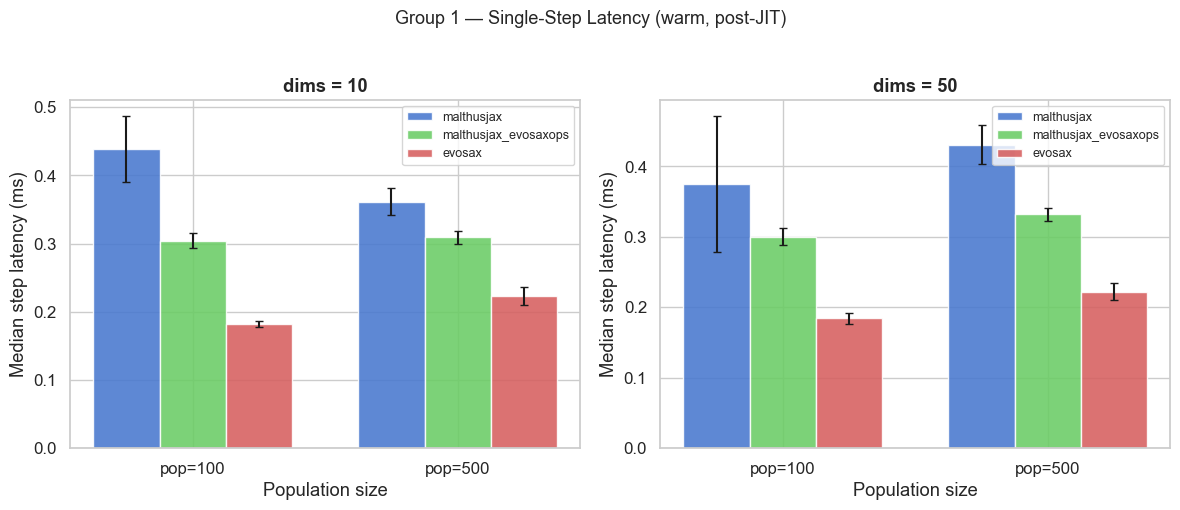

In [6]:
ss = df[df["group_prefix"] == "single_step"].copy()
dims_vals = sorted(ss["dims"].dropna().unique())
fw_order = ["malthusjax", "malthusjax_evosaxops", "evosax"]

fig, axes = plt.subplots(1, len(dims_vals), figsize=(6 * len(dims_vals), 5), sharey=False)
if len(dims_vals) == 1:
    axes = [axes]

for ax, d in zip(axes, dims_vals):
    sub = ss[ss["dims"] == d]
    pop_vals = sorted(sub["pop_size"].dropna().unique())
    x = np.arange(len(pop_vals))
    w = 0.25

    for i, fw in enumerate(fw_order):
        fw_data = sub[sub["name"] == fw].set_index("pop_size")
        medians = [fw_data.loc[p, "median_ms"] if p in fw_data.index else np.nan for p in pop_vals]
        iqrs    = [fw_data.loc[p, "iqr_ms"]    if p in fw_data.index else 0       for p in pop_vals]
        bars = ax.bar(
            x + i * w, medians, w,
            label=fw, color=PALETTE.get(fw, None),
            yerr=iqrs, capsize=3, alpha=0.88,
        )

    ax.set_title(f"dims = {int(d)}", fontweight="bold")
    ax.set_xticks(x + w)
    ax.set_xticklabels([f"pop={int(p)}" for p in pop_vals])
    ax.set_xlabel("Population size")
    ax.set_ylabel("Median step latency (ms)")
    ax.legend(fontsize=9)

fig.suptitle("Group 1 — Single-Step Latency (warm, post-JIT)", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_single_step_latency.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Evosax-Ops Overhead Heatmap
Ratio `malthusjax_evosaxops / malthusjax` median latency over the pop_size × dims grid.  
Values > 1 mean evosax ops are *slower* inside MalthusJAX's engine; values < 1 mean they are *faster*.

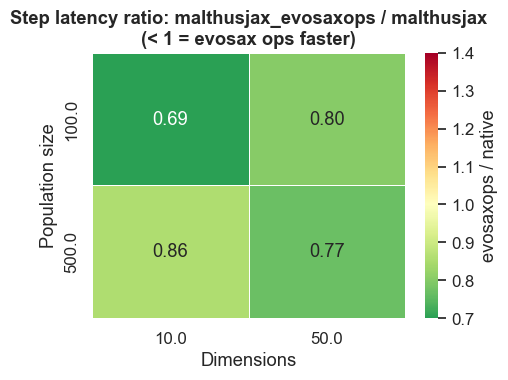

In [7]:
native = ss[ss["name"] == "malthusjax"][["pop_size", "dims", "median_ms"]].rename(columns={"median_ms": "native"})
evosax_ops = ss[ss["name"] == "malthusjax_evosaxops"][["pop_size", "dims", "median_ms"]].rename(columns={"median_ms": "evosaxops"})

ratio_df = native.merge(evosax_ops, on=["pop_size", "dims"])
ratio_df["ratio"] = ratio_df["evosaxops"] / ratio_df["native"]

pivot = ratio_df.pivot(index="pop_size", columns="dims", values="ratio")

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    pivot, annot=True, fmt=".2f", cmap="RdYlGn_r",
    center=1.0, vmin=0.7, vmax=1.4, linewidths=0.5,
    ax=ax, cbar_kws={"label": "evosaxops / native"},
)
ax.set_title("Step latency ratio: malthusjax_evosaxops / malthusjax\n(< 1 = evosax ops faster)", fontweight="bold")
ax.set_xlabel("Dimensions")
ax.set_ylabel("Population size")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_evosaxops_ratio_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Multi-Generation Scan Throughput (50 gens)
Wall-clock time for a full 50-generation `lax.scan` loop. Overhead % relative to evosax is annotated on each malthusjax bar.

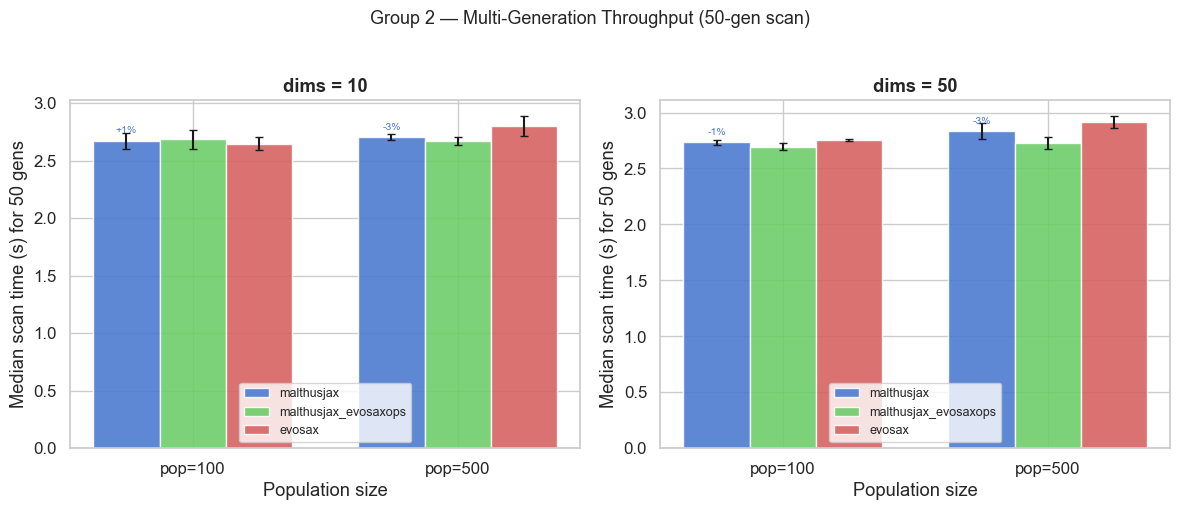

In [8]:
scan = df[df["group_prefix"] == "scan_50gen"].copy()
# Convert ms → seconds for scan (values are already in ms from load)
scan["median_s"] = scan["median_ms"] / 1e3
scan["iqr_s"]    = scan["iqr_ms"] / 1e3

dims_vals = sorted(scan["dims"].dropna().unique())
fw_order_scan = ["malthusjax", "malthusjax_evosaxops", "evosax"]

fig, axes = plt.subplots(1, len(dims_vals), figsize=(6 * len(dims_vals), 5), sharey=False)
if len(dims_vals) == 1:
    axes = [axes]

for ax, d in zip(axes, dims_vals):
    sub = scan[scan["dims"] == d]
    pop_vals = sorted(sub["pop_size"].dropna().unique())
    x = np.arange(len(pop_vals))
    w = 0.25

    for i, fw in enumerate(fw_order_scan):
        fw_data = sub[sub["name"] == fw].set_index("pop_size")
        medians = [fw_data.loc[p, "median_s"] if p in fw_data.index else np.nan for p in pop_vals]
        iqrs    = [fw_data.loc[p, "iqr_s"]    if p in fw_data.index else 0       for p in pop_vals]
        ax.bar(x + i * w, medians, w, label=fw, color=PALETTE.get(fw), yerr=iqrs, capsize=3, alpha=0.88)

    # Annotate overhead % for malthusjax vs evosax
    mjx_data = sub[sub["name"] == "malthusjax"].set_index("pop_size")
    esx_data = sub[sub["name"] == "evosax"].set_index("pop_size")
    for j, p in enumerate(pop_vals):
        if p in mjx_data.index and p in esx_data.index:
            pct = 100 * (mjx_data.loc[p, "median_s"] / esx_data.loc[p, "median_s"] - 1)
            ax.text(j + 0 * w, mjx_data.loc[p, "median_s"] + 0.05,
                    f"{pct:+.0f}%", ha="center", va="bottom", fontsize=7.5, color="#4878CF")

    ax.set_title(f"dims = {int(d)}", fontweight="bold")
    ax.set_xticks(x + w)
    ax.set_xticklabels([f"pop={int(p)}" for p in pop_vals])
    ax.set_xlabel("Population size")
    ax.set_ylabel("Median scan time (s) for 50 gens")
    ax.legend(fontsize=9)

fig.suptitle("Group 2 — Multi-Generation Throughput (50-gen scan)", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_scan_throughput.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. JIT Compilation Time Comparison

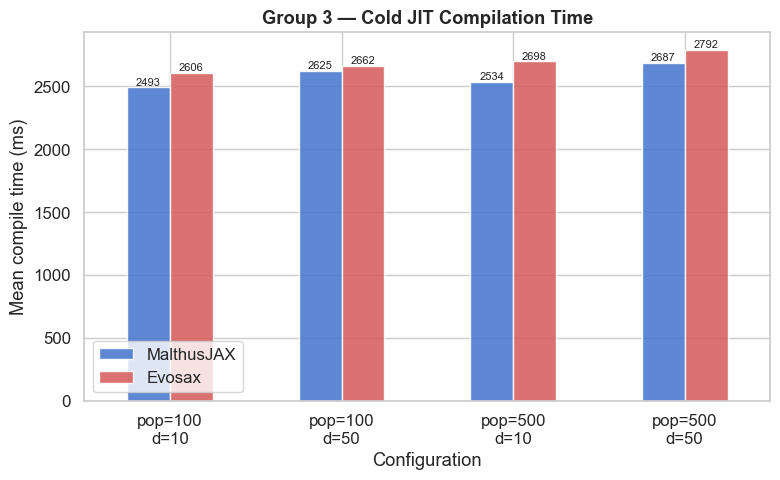

In [9]:
comp = df[df["group_prefix"] == "compile"].copy()
comp["config"] = comp.apply(lambda r: f"pop={int(r.pop_size)}\nd={int(r.dims)}", axis=1)
comp_pivot = comp.pivot(index="config", columns="name", values="mean_ms")

fig, ax = plt.subplots(figsize=(8, 5))
comp_pivot[["malthusjax", "evosax"]].plot(
    kind="bar", ax=ax,
    color=[PALETTE["malthusjax"], PALETTE["evosax"]],
    alpha=0.88, edgecolor="white",
)
ax.set_title("Group 3 — Cold JIT Compilation Time", fontweight="bold")
ax.set_xlabel("Configuration")
ax.set_ylabel("Mean compile time (ms)")
ax.legend(["MalthusJAX", "Evosax"])
ax.tick_params(axis="x", rotation=0)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.0f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_jit_compile_time.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Operator Microbenchmark Breakdown
Median latency (µs) per operator type at each (pop_size, dims) configuration.

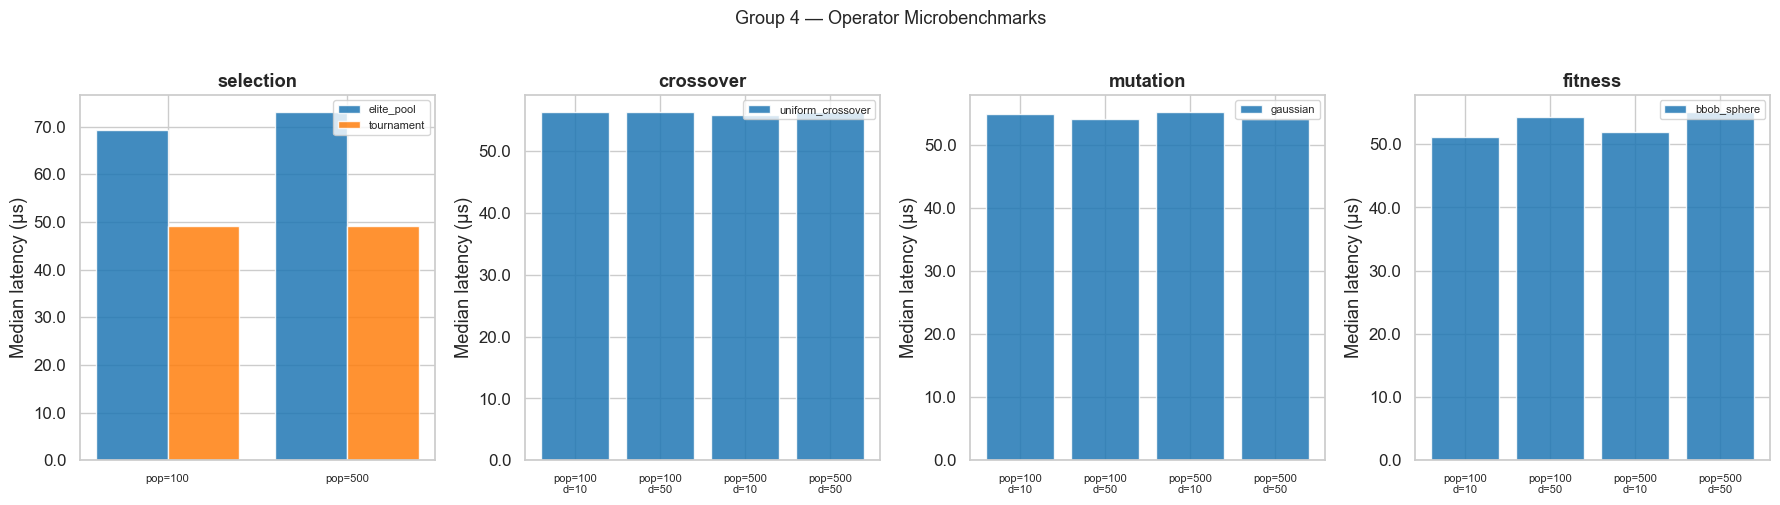

In [10]:
op_prefixes = ["operator_selection", "operator_crossover", "operator_mutation", "operator_fitness"]
ops_df = df[df["group_prefix"].isin(op_prefixes)].copy()
ops_df["op_type"] = ops_df["group_prefix"].str.replace("operator_", "")
ops_df["median_us"] = ops_df["median_ms"] * 1e3
ops_df["config"] = ops_df.apply(
    lambda r: f"pop={int(r.pop_size)}" + (f"\nd={int(r.dims)}" if pd.notna(r.dims) else ""),
    axis=1,
)

fig, axes = plt.subplots(1, len(op_prefixes), figsize=(4.5 * len(op_prefixes), 5), sharey=False)
for ax, prefix in zip(axes, op_prefixes):
    sub = ops_df[ops_df["group_prefix"] == prefix].copy()
    op_type = prefix.replace("operator_", "")
    configs = sorted(sub["config"].unique())
    ops_names = sorted(sub["name"].unique())
    x = np.arange(len(configs))
    w = 0.8 / max(len(ops_names), 1)
    cmap = plt.cm.tab10.colors
    for i, op in enumerate(ops_names):
        od = sub[sub["name"] == op].set_index("config")
        vals = [od.loc[c, "median_us"] if c in od.index else np.nan for c in configs]
        ax.bar(x + i * w - (len(ops_names) - 1) * w / 2, vals, w, label=op, color=cmap[i], alpha=0.85)
    ax.set_title(f"{op_type}", fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(configs, fontsize=8)
    ax.set_ylabel("Median latency (µs)")
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}"))

fig.suptitle("Group 4 — Operator Microbenchmarks", fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "05_operator_microbenchmarks.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Step Phase Breakdown (MalthusJAX Internal)
Cost attribution at pop=500, d=10. The "overhead" bar is `full_step − Σ(measured phases)`.

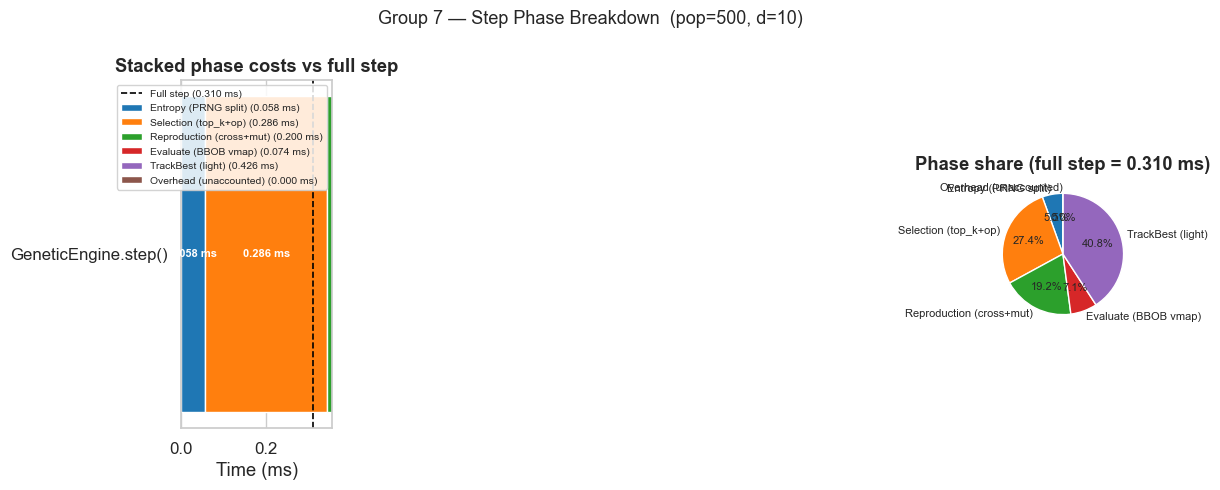

In [11]:
phases = df[df["group_prefix"] == "phase_breakdown"].copy()
phase_lookup = phases.set_index("name")["median_ms"].to_dict()

full_step = phase_lookup.get("00_full_step", np.nan)
phase_names  = ["01_entropy", "02_selection", "03_reproduction", "04_evaluate", "05_trackbest_light"]
phase_labels = ["Entropy\n(PRNG split)", "Selection\n(top_k+op)", "Reproduction\n(cross+mut)", "Evaluate\n(BBOB vmap)", "TrackBest\n(light)"]
phase_vals   = [phase_lookup.get(p, 0.0) for p in phase_names]
accounted    = sum(phase_vals)
overhead     = max(0.0, full_step - accounted)

all_vals   = phase_vals + [overhead]
all_labels = phase_labels + ["Overhead\n(unaccounted)"]
colors = sns.color_palette("tab10", len(all_vals))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ── left: stacked horizontal bar ────────────────────────────────────────────
left = 0
for val, label, color in zip(all_vals, all_labels, colors):
    ax1.barh(["GeneticEngine.step()"], val, left=left, color=color, label=f"{label.replace(chr(10),' ')} ({val:.3f} ms)")
    if val > 0.005:
        ax1.text(left + val / 2, 0, f"{val:.3f} ms", va="center", ha="center", fontsize=8, color="white", fontweight="bold")
    left += val
ax1.axvline(full_step, color="black", linestyle="--", linewidth=1.2, label=f"Full step ({full_step:.3f} ms)")
ax1.set_xlabel("Time (ms)")
ax1.set_title("Stacked phase costs vs full step", fontweight="bold")
ax1.legend(loc="upper right", fontsize=7.5, framealpha=0.85)
ax1.set_xlim(0, full_step * 1.15)

# ── right: pie chart ────────────────────────────────────────────────────────
wedge_labels = [l.replace("\n", " ") for l in all_labels]
ax2.pie(all_vals, labels=wedge_labels, colors=colors, autopct="%1.1f%%", startangle=90,
        textprops={"fontsize": 8})
ax2.set_title(f"Phase share (full step = {full_step:.3f} ms)", fontweight="bold")

fig.suptitle("Group 7 — Step Phase Breakdown  (pop=500, d=10)", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "06_phase_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Elite Extraction: `top_k` vs `argpartition`

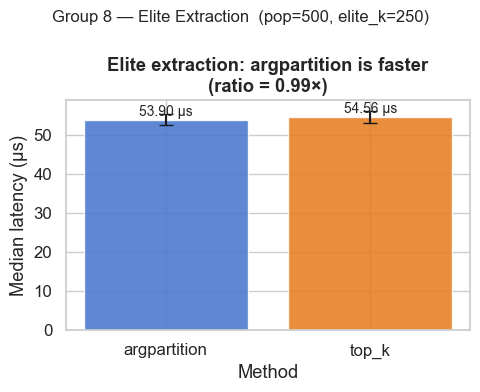

In [12]:
elite = df[df["group_prefix"] == "elite_extraction"].copy()
elite["median_us"] = elite["median_ms"] * 1e3
elite["iqr_us"]    = elite["iqr_ms"] * 1e3

names  = elite["name"].tolist()
vals   = elite["median_us"].tolist()
errs   = elite["iqr_us"].tolist()
colors = [PALETTE.get("malthusjax", "#4878CF"), "#E67E22"]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(names, vals, yerr=errs, capsize=5, color=colors, alpha=0.88, edgecolor="white")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.3, f"{v:.2f} µs", ha="center", va="bottom", fontsize=10)

if len(vals) == 2:
    speedup = vals[0] / vals[1]  # argpartition / top_k — if argpartition wins it should be < 1
    faster = "argpartition" if vals[0] < vals[1] else "top_k"
    ax.set_title(
        f"Elite extraction: {faster} is faster\n(ratio = {min(vals)/max(vals):.2f}×)",
        fontweight="bold"
    )

ax.set_ylabel("Median latency (µs)")
ax.set_xlabel("Method")
fig.suptitle("Group 8 — Elite Extraction  (pop=500, elite_k=250)", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "07_elite_extraction.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Unroll Factor Sweep
How `lax.scan` `unroll_num` affects 50-gen wall-clock time at pop=100, d=10.

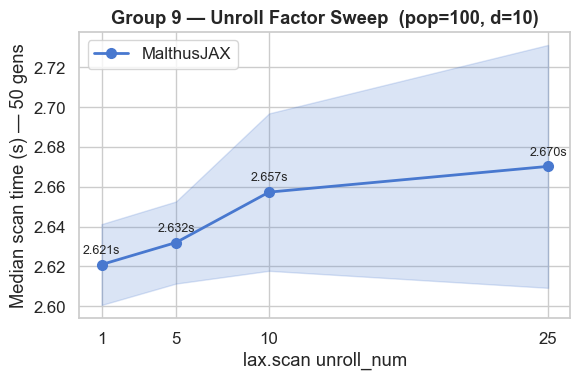

In [13]:
unroll = df[df["group_prefix"] == "unroll_scan_50gen"].copy()
unroll["unroll_factor"] = unroll["name"].str.extract(r"unroll_(\d+)").astype(int)
unroll = unroll.sort_values("unroll_factor")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(unroll["unroll_factor"], unroll["median_ms"] / 1e3, "o-",
        color=PALETTE["malthusjax"], linewidth=2, markersize=7, label="MalthusJAX")
for _, row in unroll.iterrows():
    ax.annotate(f"{row['median_ms']/1e3:.3f}s",
                (row["unroll_factor"], row["median_ms"] / 1e3),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)

ax.fill_between(unroll["unroll_factor"],
                (unroll["median_ms"] - unroll["iqr_ms"]) / 1e3,
                (unroll["median_ms"] + unroll["iqr_ms"]) / 1e3,
                alpha=0.2, color=PALETTE["malthusjax"])
ax.set_xlabel("lax.scan unroll_num")
ax.set_ylabel("Median scan time (s) — 50 gens")
ax.set_xticks(unroll["unroll_factor"])
ax.set_title("Group 9 — Unroll Factor Sweep  (pop=100, d=10)", fontweight="bold")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "08_unroll_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Population Scaling Curves
Log-log plot of median step latency vs population size (d=10). A power-law fit reveals the empirical scaling exponent (O(N) = slope 1; O(N²) = slope 2).

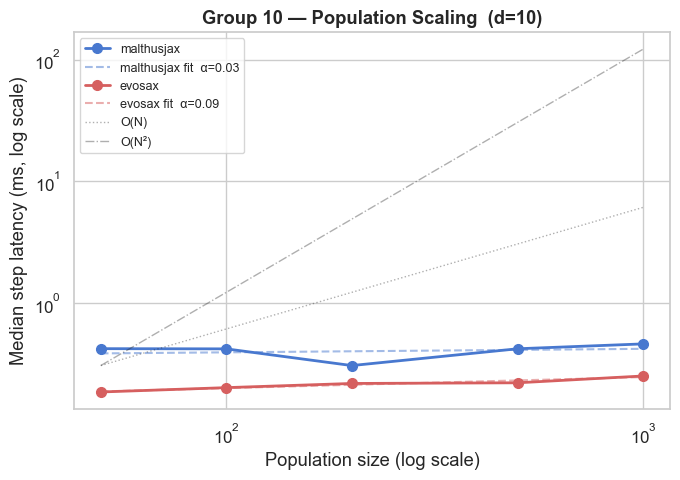

In [14]:
scaling = df[df["group_prefix"] == "scaling_d10"].copy()

def _parse_fw_pop(name: str):
    """Split 'malthusjax_pop500' → ('malthusjax', 500)."""
    m = re.match(r"(.+?)_pop(\d+)$", name)
    if m:
        return m.group(1), int(m.group(2))
    return name, None

scaling[["framework", "pop_size_parsed"]] = scaling["name"].apply(
    lambda n: pd.Series(_parse_fw_pop(n))
)
scaling["pop_size_parsed"] = scaling["pop_size_parsed"].astype(float)

fig, ax = plt.subplots(figsize=(7, 5))
for fw, color in [("malthusjax", PALETTE["malthusjax"]), ("evosax", PALETTE["evosax"])]:
    sub = scaling[scaling["framework"] == fw].sort_values("pop_size_parsed")
    pops = sub["pop_size_parsed"].values
    meds = sub["median_ms"].values

    ax.loglog(pops, meds, "o-", color=color, linewidth=2, markersize=7, label=fw)

    # Power-law fit: log(y) = a * log(x) + b
    if len(pops) >= 2:
        coeffs = np.polyfit(np.log(pops), np.log(meds), 1)
        slope = coeffs[0]
        fit_y = np.exp(np.polyval(coeffs, np.log(pops)))
        ax.loglog(pops, fit_y, "--", color=color, alpha=0.5,
                  label=f"{fw} fit  α={slope:.2f}")

ax.set_xlabel("Population size (log scale)")
ax.set_ylabel("Median step latency (ms, log scale)")
ax.set_title("Group 10 — Population Scaling  (d=10)", fontweight="bold")
ax.legend(fontsize=9)
# Reference lines
pop_ref = np.array([50, 1000])
y0 = scaling[scaling["framework"] == "malthusjax"]["median_ms"].min()
ax.loglog(pop_ref, y0 * (pop_ref / pop_ref[0]) ** 1, "k:", alpha=0.35, linewidth=1, label="O(N)")
ax.loglog(pop_ref, y0 * (pop_ref / pop_ref[0]) ** 2, "k-.", alpha=0.35, linewidth=1, label="O(N²)")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "09_scaling_curves.png", dpi=150, bbox_inches="tight")
plt.show()